# Closed-Loop Optogenetic Feedback Control

This notebook demonstrates a closed-loop feedback control pipeline using the virtual microscope:

1. **Snap** a phase-contrast image
2. **Segment** cells via Otsu thresholding + contour detection
3. **Compute** an SLM mask that places illumination spots above each cell centroid
4. **Apply** the mask — optogenetic cells migrate toward the light
5. **Wait** for the sample to respond
6. **Repeat**

We use the **optogenetic** backend: vertex-model cells that respond to SLM
illumination with increased contractility and directed migration. By placing
illumination spots above each cell, we steer the population upward over time.

In [1]:
import time

import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from virtual_microscope.backends import load_backend

## 1. Set up the microscope
The feedback loop we will implement looks like this:

```python
for frame in range(n_frames):
    core.setConfig("Channel", "phase-contrast")
    core.snapImage()
    img = core.getImage()

    cells = detect_cells(img)              # segment cells from the image
    mask = build_steer_mask(cells)         # SLM spots above each centroid
    core.setSLMImage("SLM", mask)          # apply optogenetic illumination

    time.sleep(1.5)                        # wait for cells to respond
```

`load_backend` returns a pymmcore-plus `core` object and a simulation handle.
The `RealtimeEngine` runs in the background, advancing the simulation between snaps.

In [2]:
core, sim = load_backend("optogenetic", n_cells=20, seed=0)

print("Channels:", core.getAvailableConfigs("Channel"))
print("Exposure:", core.getExposure(), "ms")

Channels: ('DAPI', 'membrane', 'phase-contrast')
Exposure: 50.0 ms


## 2. Helper functions

- **`detect_cells`** — Segments cells from a phase-contrast image using Otsu
  thresholding, finds external contours, and returns the centroid `(cx, cy)` and
  area of each cell. Small fragments below `min_area` are filtered out.
- **`build_steer_mask`** — Creates a binary SLM mask with a filled circle
  (`spot_radius`) placed `direction_px` pixels above each cell centroid. Negative
  `direction_px` means upward — so each illumination spot acts as a waypoint that
  pulls its cell toward it via optogenetic actuation.

In [3]:
def snap(core, channel="phase-contrast"):
    """Snap an image on the given channel."""
    core.setConfig("Channel", channel)
    core.snapImage()
    return core.getImage()


def detect_cells(img, min_area=100):
    """Segment cells from a phase-contrast image using Otsu thresholding.

    Returns a list of (cx, cy, area) tuples for each detected cell.
    """
    _, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cells = []
    for c in contours:
        area = cv2.contourArea(c)
        if area < min_area:
            continue
        M = cv2.moments(c)
        if M["m00"] == 0:
            continue
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
        cells.append((cx, cy, area))
    return cells


def build_steer_mask(cells, direction_px=-15, spot_radius=11, shape=(512, 512)):
    """Build an SLM mask that illuminates a spot offset from each cell centre.

    direction_px < 0 means upward (negative y). Each illuminated spot
    pulls the cell toward it via optogenetic actuation.
    """
    mask = np.zeros(shape, dtype=np.uint8)
    for cx, cy, _ in cells:
        target_y = int(np.clip(cy + direction_px, 0, shape[0] - 1))
        cv2.circle(mask, (cx, target_y), spot_radius, 255, -1)
    return mask


def overlay_mask(img, mask, color=(80, 140, 255), alpha=0.4):
    """Overlay SLM mask on an inverted grayscale image as a coloured wash."""
    # Normalize to full range then invert (matches matplotlib gray_r auto-scaling)
    lo, hi = float(img.min()), float(img.max())
    if hi > lo:
        norm = (img.astype(np.float32) - lo) / (hi - lo) * 255
    else:
        norm = img.astype(np.float32)
    inv = 255 - norm
    rgb = np.stack([inv] * 3, axis=-1)
    region = mask > 0
    for ch, val in enumerate(color):
        rgb[region, ch] = rgb[region, ch] * (1 - alpha) + val * alpha
    return rgb.clip(0, 255).astype(np.uint8)

## 3. Baseline — snap before any stimulation

Detected 17 cells


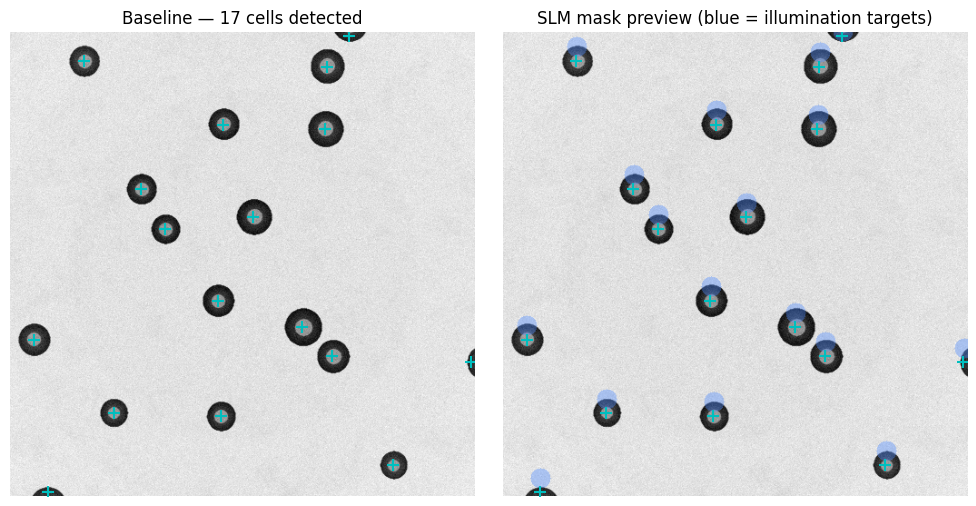

In [4]:
img_before = snap(core)
cells_before = detect_cells(img_before)
print(f"Detected {len(cells_before)} cells")

# Preview: baseline image with SLM mask overlay
mask_preview = build_steer_mask(cells_before, direction_px=-15, spot_radius=11)
display_preview = overlay_mask(img_before, mask_preview)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img_before, cmap="gray_r")
for cx, cy, _ in cells_before:
    axes[0].plot(cx, cy, "c+", ms=8, mew=1.5)
axes[0].set_title(f"Baseline — {len(cells_before)} cells detected")
axes[0].axis("off")

axes[1].imshow(display_preview)
for cx, cy, _ in cells_before:
    axes[1].plot(cx, cy, "c+", ms=8, mew=1.5)
axes[1].set_title("SLM mask preview (blue = illumination targets)")
axes[1].axis("off")

plt.tight_layout()

In [13]:
n_frames = 100
wait_seconds = 0.1  # time between feedback updates

# Reset the simulation
sim.reset()

# Track cell centroids over time for plotting tracks
centroid_history = []
all_images = []
all_masks = []
snapshots = []
snapshot_frames = np.linspace(0, n_frames - 1, 4, dtype=int)

pbar = tqdm(range(n_frames), desc="Feedback loop")
for i in pbar:
    # 1. Snap
    img = snap(core)

    # 2. Detect cells
    cells = detect_cells(img)
    centroids = np.array([(cx, cy) for cx, cy, _ in cells])
    centroid_history.append(centroids)

    # 3. Build SLM mask — spots above each cell to steer upward
    mask = build_steer_mask(cells, direction_px=-15, spot_radius=11)

    # 4. Apply mask
    core.setSLMImage("SLM", mask)

    # Store every frame for movie
    all_images.append(img.copy())
    all_masks.append(mask.copy())

    # Save select snapshots for the static figure
    if i in snapshot_frames:
        snapshots.append((i, img.copy(), mask.copy(), centroids.copy()))

    # 5. Wait — RealtimeEngine steps the simulation in the background
    time.sleep(wait_seconds)

    mean_y = centroids[:, 1].mean() if len(centroids) > 0 else 0
    pbar.set_postfix(cells=len(cells), mean_y=f"{mean_y:.0f}")

last_img = all_images[-1]

Feedback loop:   0%|          | 0/100 [00:00<?, ?it/s]

In [5]:
n_frames = 100
wait_seconds = 0.1  # time between feedback updates

# Reset the simulation
sim.reset()

# Track cell centroids over time for plotting tracks
centroid_history = []
all_images = []
all_masks = []
snapshots = []
snapshot_frames = np.linspace(0, n_frames - 1, 4, dtype=int)

for i in range(n_frames):
    # 1. Snap
    img = snap(core)

    # 2. Detect cells
    cells = detect_cells(img)
    centroids = np.array([(cx, cy) for cx, cy, _ in cells])
    centroid_history.append(centroids)

    # 3. Build SLM mask — spots above each cell to steer upward
    mask = build_steer_mask(cells, direction_px=-15, spot_radius=11)

    # 4. Apply mask
    core.setSLMImage("SLM", mask)

    # Store every frame for movie
    all_images.append(img.copy())
    all_masks.append(mask.copy())

    # Save select snapshots for the static figure
    if i in snapshot_frames:
        snapshots.append((i, img.copy(), mask.copy(), centroids.copy()))

    # 5. Wait — RealtimeEngine steps the simulation in the background
    time.sleep(wait_seconds)

    mean_y = centroids[:, 1].mean() if len(centroids) > 0 else 0
    print(f"Frame {i+1:2d}: {len(cells)} cells, mean Y = {mean_y:.0f}")

last_img = all_images[-1]

Frame  1: 16 cells, mean Y = 279
Frame  2: 16 cells, mean Y = 277
Frame  3: 16 cells, mean Y = 276
Frame  4: 16 cells, mean Y = 275
Frame  5: 16 cells, mean Y = 274
Frame  6: 16 cells, mean Y = 273
Frame  7: 16 cells, mean Y = 273
Frame  8: 16 cells, mean Y = 272
Frame  9: 16 cells, mean Y = 271
Frame 10: 16 cells, mean Y = 271
Frame 11: 16 cells, mean Y = 270
Frame 12: 16 cells, mean Y = 269
Frame 13: 16 cells, mean Y = 269
Frame 14: 16 cells, mean Y = 268
Frame 15: 16 cells, mean Y = 268
Frame 16: 16 cells, mean Y = 267
Frame 17: 16 cells, mean Y = 266
Frame 18: 16 cells, mean Y = 266
Frame 19: 16 cells, mean Y = 265
Frame 20: 16 cells, mean Y = 265
Frame 21: 16 cells, mean Y = 264
Frame 22: 16 cells, mean Y = 264
Frame 23: 16 cells, mean Y = 263
Frame 24: 16 cells, mean Y = 263
Frame 25: 16 cells, mean Y = 262
Frame 26: 16 cells, mean Y = 262
Frame 27: 16 cells, mean Y = 261
Frame 28: 16 cells, mean Y = 261
Frame 29: 16 cells, mean Y = 260
Frame 30: 16 cells, mean Y = 260
Frame 31: 

## 5. Visualise the time-lapse

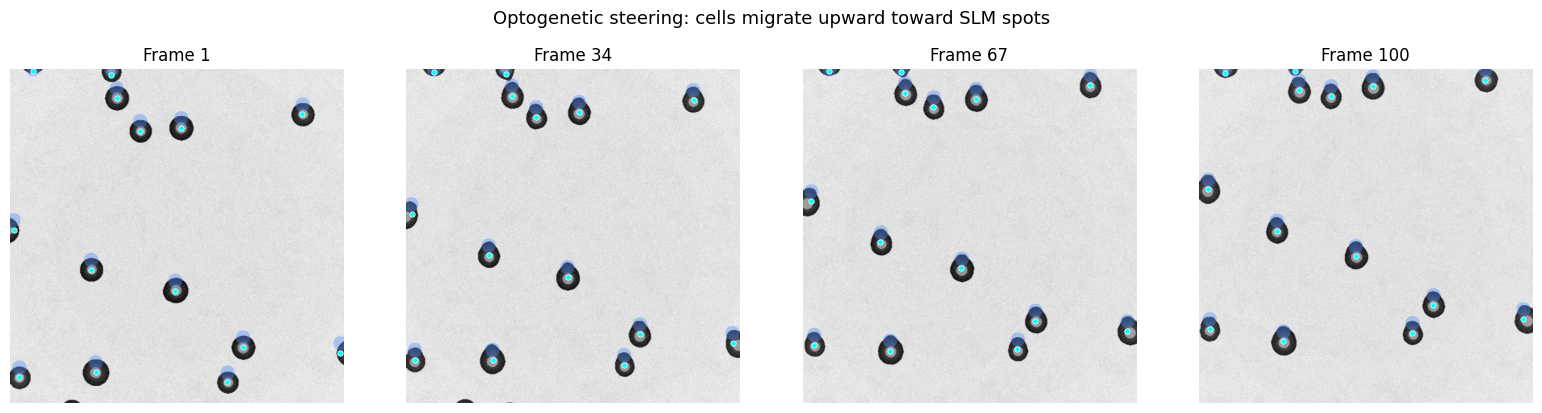

In [14]:
fig, axes = plt.subplots(1, len(snapshots), figsize=(4 * len(snapshots), 4))

for ax, (it, img, mask, centroids) in zip(axes, snapshots):
    display = overlay_mask(img, mask)
    ax.imshow(display)
    if len(centroids) > 0:
        ax.scatter(centroids[:, 0], centroids[:, 1], c="cyan", s=15,
                   edgecolors="white", linewidths=0.5, zorder=5)
    ax.set_title(f"Frame {it + 1}")
    ax.axis("off")

plt.suptitle("Optogenetic steering: cells migrate upward toward SLM spots",
             y=1.02, fontsize=13)
plt.tight_layout()

## 6. Plot migration tracks

/Users/luhin/miniforge3/envs/virtual-env/lib/python3.12/site-packages/numpy/_core/numeric.py:476: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


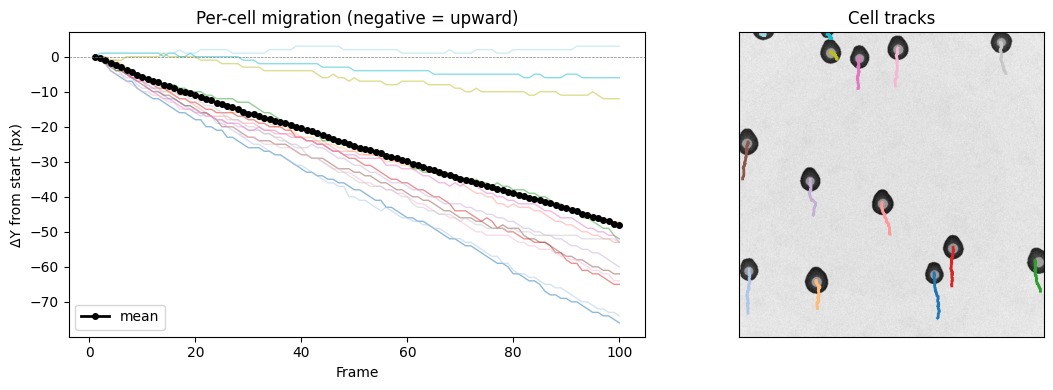

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: normalised Y position of each cell over time
ax = axes[0]
if len(centroid_history) >= 2 and len(centroid_history[0]) > 0:
    n_cells_tracked = len(centroid_history[0])
    tracks = [centroid_history[0]]
    for frame_centroids in centroid_history[1:]:
        if len(frame_centroids) == 0:
            break
        prev = tracks[-1]
        matched = np.zeros(len(frame_centroids), dtype=bool)
        new_frame = np.full_like(prev, np.nan)
        for j in range(len(prev)):
            if np.isnan(prev[j, 0]):
                continue
            dists = np.linalg.norm(frame_centroids - prev[j], axis=1)
            dists[matched] = np.inf
            best = np.argmin(dists)
            if dists[best] < 60:
                new_frame[j] = frame_centroids[best]
                matched[best] = True
        tracks.append(new_frame)

    # Plot normalised Y for each cell (Y_0 = 0, negative = upward migration)
    cmap = plt.cm.tab20
    frames = np.arange(1, len(tracks) + 1)
    for j in range(n_cells_tracked):
        ys = np.array([t[j, 1] for t in tracks])
        if np.isnan(ys[0]):
            continue
        ys_norm = ys - ys[0]  # normalise to starting position
        valid = ~np.isnan(ys_norm)
        ax.plot(frames[valid], ys_norm[valid], "-", alpha=0.5,
                color=cmap(j / max(1, n_cells_tracked - 1)), lw=1)

    # Mean normalised trajectory
    all_norm = np.array([
        np.array([t[j, 1] for t in tracks]) - tracks[0][j, 1]
        for j in range(n_cells_tracked) if not np.isnan(tracks[0][j, 0])
    ])
    mean_norm = np.nanmean(all_norm, axis=0)
    ax.plot(frames, mean_norm, "k-o", ms=4, lw=2, label="mean")
    ax.axhline(0, color="gray", ls="--", lw=0.5)
    ax.legend()

ax.set_xlabel("Frame")
ax.set_ylabel("ΔY from start (px)")
ax.set_title("Per-cell migration (negative = upward)")

# Right: individual cell tracks on last loop image
ax = axes[1]
# Use overlay_mask with an empty mask to get a properly normalised inverted background
ax.imshow(overlay_mask(last_img, np.zeros_like(last_img)))

if len(centroid_history) >= 2 and len(centroid_history[0]) > 0:
    for j in range(n_cells_tracked):
        xs = [t[j, 0] for t in tracks if not np.isnan(t[j, 0])]
        ys = [t[j, 1] for t in tracks if not np.isnan(t[j, 1])]
        if len(xs) >= 2:
            color = cmap(j / max(1, n_cells_tracked - 1))
            ax.plot(xs, ys, "-", color=color, lw=2, alpha=1)

ax.set_title("Cell tracks")
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()

## 7. Export time-lapse movie

Render each frame with the SLM overlay and accumulated cell tracks, then save as MP4.

In [17]:
import subprocess
from IPython.display import Video

# Build tracks for movie (same nearest-neighbour matching as above)
movie_tracks = [centroid_history[0]]
for frame_centroids in centroid_history[1:]:
    if len(frame_centroids) == 0:
        break
    prev = movie_tracks[-1]
    matched = np.zeros(len(frame_centroids), dtype=bool)
    new_frame = np.full_like(prev, np.nan)
    for j in range(len(prev)):
        if np.isnan(prev[j, 0]):
            continue
        dists = np.linalg.norm(frame_centroids - prev[j], axis=1)
        dists[matched] = np.inf
        best = np.argmin(dists)
        if dists[best] < 60:
            new_frame[j] = frame_centroids[best]
            matched[best] = True
    movie_tracks.append(new_frame)

n_cells_movie = len(movie_tracks[0])
track_cmap = plt.cm.tab20

# Render all frames into a list
rendered_frames = []
for i in range(len(all_images)):
    rgb = overlay_mask(all_images[i], all_masks[i])

    for j in range(n_cells_movie):
        xs = [movie_tracks[t][j, 0] for t in range(i + 1) if not np.isnan(movie_tracks[t][j, 0])]
        ys = [movie_tracks[t][j, 1] for t in range(i + 1) if not np.isnan(movie_tracks[t][j, 1])]
        if len(xs) >= 2:
            color_f = track_cmap(j / max(1, n_cells_movie - 1))
            color_bgr = (int(color_f[2] * 255), int(color_f[1] * 255), int(color_f[0] * 255))
            pts = np.array(list(zip(xs, ys)), dtype=np.int32)
            cv2.polylines(rgb, [pts], isClosed=False, color=color_bgr, thickness=2,
                          lineType=cv2.LINE_AA)

    cv2.putText(rgb, f"Frame {i + 1}", (12, 30), cv2.FONT_HERSHEY_SIMPLEX,
                0.8, (0, 0, 0), 2, cv2.LINE_AA)
    rendered_frames.append(rgb)

# Encode as H.264 MP4 via ffmpeg (browser-compatible)
movie_path = "feedback_control.mp4"
fps = 20
h, w = rendered_frames[0].shape[:2]
proc = subprocess.Popen(
    ["ffmpeg", "-y", "-f", "rawvideo", "-pix_fmt", "rgb24",
     "-s", f"{w}x{h}", "-r", str(fps), "-i", "-",
     "-c:v", "libx264", "-pix_fmt", "yuv420p", "-movflags", "+faststart",
     movie_path],
    stdin=subprocess.PIPE, stdout=subprocess.DEVNULL, stderr=subprocess.PIPE,
)
for frame in rendered_frames:
    proc.stdin.write(frame.tobytes())
proc.stdin.close()
proc.wait()
print(f"Saved {movie_path} ({len(rendered_frames)} frames, {fps} fps)")

Video(movie_path, embed=True, width=512)

/Users/luhin/miniforge3/envs/virtual-env/lib/python3.12/site-packages/numpy/_core/numeric.py:476: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


Saved feedback_control.mp4 (100 frames, 20 fps)


## Note

This is a simplified version of a feedback control loop — in practice you would
use an event-driven acquisition engine with hardware-triggered callbacks rather
than `time.sleep()` polling. See:

- [pymmcore-plus: Event-Driven Acquisition](https://pymmcore-plus.github.io/pymmcore-plus/guides/event_driven_acquisition/) — technical background on MDA-based acquisition
- [rtm-pymmcore](https://github.com/pertzlab/rtm-pymmcore) — a project that implements feedback-control photomanipulation on real hardware using this approach

To run this notebook on real hardware, replace `load_backend(...)` with your
`CMMCorePlus` setup and swap `detect_cells` for your segmentation model.